# House Price Prediction in Tehran

Predicting apartment prices in Tehran with linear regression, using area, rooms, parking, warehouse, elevator and neighbourhood.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


In [4]:
df['Address'].nunique()

192

In [5]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


## 2. Fixing the Area column

`Area` was stored as text with commas. After converting it to numbers, a few rows had prices typed into the Area column (values in the billions), so I remove anything that isn't a realistic size and check the largest remaining properties.

In [6]:
df['Area'] = pd.to_numeric(df['Area'].str.replace(',', ''))

In [7]:
df = df[df['Area']<3000]

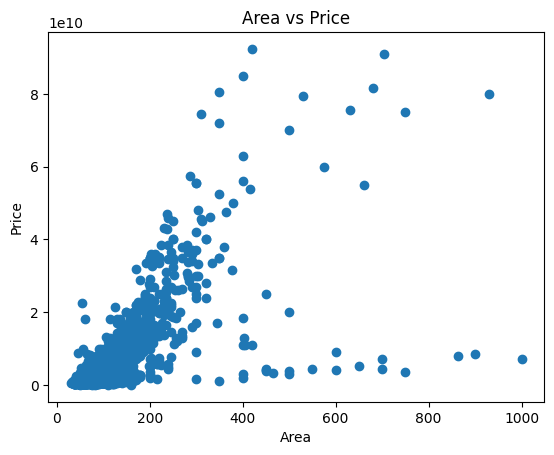

In [8]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [9]:
len(df)

3474

In [10]:
weird = df[(df['Area']>600) & (df['Price']<40000000000)]

In [11]:
weird

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
356,650,2,True,True,False,Absard,5.200000e+09,173333.33
573,863,2,True,True,True,Gheitarieh,7.830000e+09,261000.00
807,1000,2,True,True,False,Damavand,7.000000e+09,233333.33
1974,900,3,True,True,False,Damavand,8.500000e+09,283333.33
2481,700,3,True,True,False,Damavand,4.500000e+09,150000.00
2647,700,3,True,True,False,Damavand,7.000000e+09,233333.33
3115,750,5,True,True,False,Varamin - Beheshti,3.500000e+09,116666.67


In [12]:
df = df.drop(573)

## 3. Price per m² and missing neighbourhoods

Price per m² makes it easier to compare houses of different sizes and spot suspicious listings. Rows with no neighbourhood are dropped.

In [13]:
df['Price Per Meter'] = df['Price'] / df['Area']

In [14]:
df.isna().sum()

Area                0
Room                0
Parking             0
Warehouse           0
Elevator            0
Address            23
Price               0
Price(USD)          0
Price Per Meter     0
dtype: int64

In [15]:
len(df)

3473

In [16]:
df['Address'] = df['Address'].str.strip()
df = df.dropna()

In [17]:
df['Address'].nunique()

192

## 4. Outliers in price per m²

Looking at the most expensive listings per m² to find data-entry errors, such as small apartments priced like luxury homes.

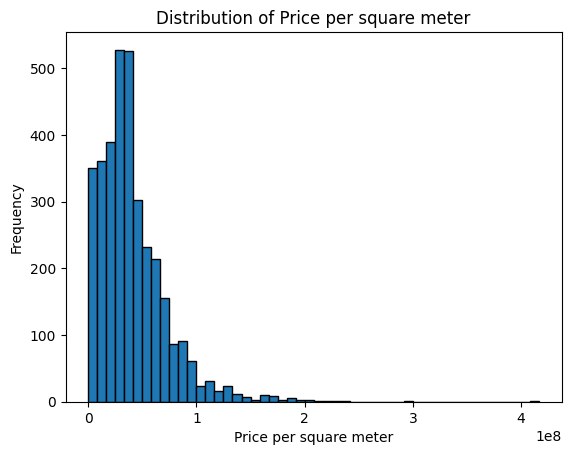

In [18]:
plt.hist(df['Price Per Meter'], bins=50, edgecolor='black')
plt.xlabel('Price per square meter')
plt.ylabel('Frequency')
plt.title('Distribution of Price per square meter')
plt.show()

In [19]:
df['Price Per Meter'].describe()

count    3.450000e+03
mean     4.127364e+07
std      3.165894e+07
min      2.250000e+04
25%      2.000000e+07
50%      3.472953e+07
75%      5.497232e+07
max      4.166667e+08
Name: Price Per Meter, dtype: float64

In [20]:
df.nlargest(10, 'Price Per Meter')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3394,54,1,True,True,True,West Ferdows Boulevard,2.250000e+10,750000.00,4.166667e+08
3132,60,1,False,False,False,Shahr-e-Ziba,1.800000e+10,600000.00,3.000000e+08
2394,310,3,True,True,True,Aqdasieh,7.440000e+10,2480000.00,2.400000e+08
1332,350,4,True,True,True,Niavaran,8.050000e+10,2683333.33,2.300000e+08
1707,420,4,True,True,True,Zaferanieh,9.240000e+10,3080000.00,2.200000e+08
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
2194,350,4,True,True,True,Niavaran,7.200000e+10,2400000.00,2.057143e+08
1635,287,5,True,True,False,Vanak,5.750000e+10,1916666.67,2.003484e+08
3420,45,1,False,False,True,Si Metri Ji,8.900000e+09,296666.67,1.977778e+08
1565,238,3,True,True,True,Velenjak,4.690000e+10,1563333.33,1.970588e+08


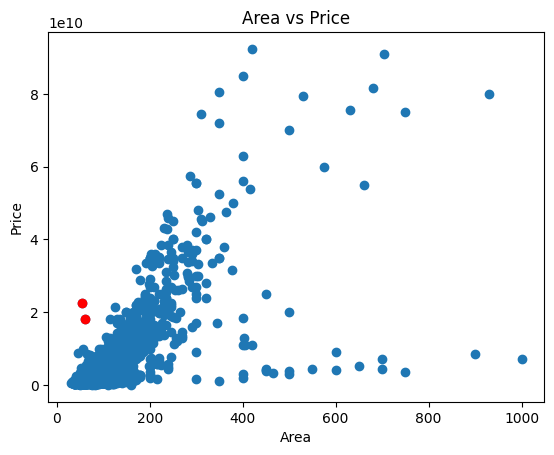

In [21]:
plt.scatter(df['Area'], df['Price'])
row = df.loc[[3132, 3394]]
plt.scatter(row['Area'], row['Price'], color='red')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [22]:
df = df.drop([3132, 3394])

## 5. Neighbourhoods

The neighbourhood is the strongest driver of price. Here I check the most expensive areas and how many listings each neighbourhood has, since averages from 1–2 listings aren't reliable.

In [23]:
df.groupby('Address')['Price Per Meter'].mean().sort_values(ascending=False).head(10)

Address
Gandhi        1.400000e+08
Vanak         1.274156e+08
Lavasan       1.172917e+08
Zaferanieh    1.137139e+08
Elahieh       1.122126e+08
Velenjak      1.116799e+08
Kamranieh     1.036243e+08
Niavaran      1.027806e+08
Farmanieh     1.023298e+08
Aqdasieh      9.088586e+07
Name: Price Per Meter, dtype: float64

In [24]:
gandhi = df[df['Address'].str.contains('Gandhi')]

In [25]:
gandhi.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,1.0,1.0,1.000000e+00,1.00,1.0
mean,500.0,5.0,7.000000e+10,2333333.33,140000000.0
std,NaN,NaN,NaN,NaN,NaN
min,500.0,5.0,7.000000e+10,2333333.33,140000000.0
25%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
50%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
75%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
max,500.0,5.0,7.000000e+10,2333333.33,140000000.0


In [26]:
vanak = df[df['Address'].str.contains('Vanak')]
vanak.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,2.000000,2.000000,2.000000e+00,2.000000e+00,2.000000e+00
mean,216.000000,4.000000,3.270000e+10,1.090000e+06,1.274156e+08
std,100.409163,1.414214,3.507250e+10,1.169083e+06,1.031426e+08
min,145.000000,3.000000,7.900000e+09,2.633333e+05,5.448276e+07
25%,180.500000,3.500000,2.030000e+10,6.766667e+05,9.094918e+07
50%,216.000000,4.000000,3.270000e+10,1.090000e+06,1.274156e+08
75%,251.500000,4.500000,4.510000e+10,1.503333e+06,1.638820e+08
max,287.000000,5.000000,5.750000e+10,1.916667e+06,2.003484e+08


In [27]:
counts = df['Address'].value_counts()
rare = counts[counts < 10]
with pd.option_context('display.max_rows', None):
    display(rare)

Address
Gisha                      9
Kook                       9
Dezashib                   9
Ray                        9
Fallah                     9
Dehkade Olampic            9
Araj                       9
East Pars                  8
Tehransar                  8
Parastar                   8
Mehran                     8
Shams Abad                 8
Baghestan                  8
Valiasr                    7
Tajrish                    7
Razi                       7
Ekbatan                    7
Hor Square                 6
Tarasht                    6
Sadeghieh                  6
Afsarieh                   6
Absard                     6
Ajudaniye                  5
Hakimiyeh                  5
Shahedshahr                5
Shahrake Quds              5
Azadshahr                  5
ShahrAra                   5
Qarchak                    5
Southern Chitgar           5
Mahallati                  4
Republic                   4
Eskandari                  4
Heshmatieh                 4
Amir B

In [28]:
elahieh = df[df['Address'] == 'Elahieh']
elahieh.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,17.000000,17.000000,1.700000e+01,1.700000e+01,1.700000e+01
mean,217.235294,2.941176,2.678635e+10,8.928784e+05,1.122126e+08
std,102.835141,0.899346,1.762597e+10,5.875322e+05,4.385208e+07
min,41.000000,1.000000,8.150000e+08,2.716667e+04,1.987805e+07
25%,150.000000,3.000000,1.150000e+10,3.833333e+05,7.823129e+07
50%,204.000000,3.000000,3.166800e+10,1.055600e+06,1.145833e+08
75%,250.000000,3.000000,3.850000e+10,1.283333e+06,1.575000e+08
max,400.000000,4.000000,6.300000e+10,2.100000e+06,1.604167e+08


## 6. Parking, elevator, warehouse and rooms

Checking how each feature relates to price and investigating listings that don't fit the pattern (e.g. a very expensive house with no parking, or prices far too low to be real).

<Axes: xlabel='Parking', ylabel='Price'>

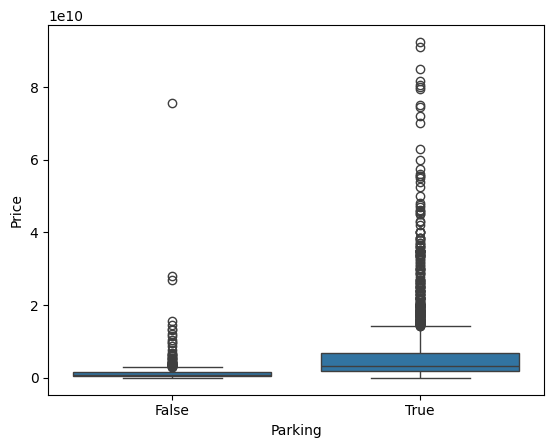

In [29]:
sns.boxplot(data=df, x='Parking', y='Price')

In [30]:
nopark = df[df['Parking'] == False]
nopark.nlargest(10, 'Price')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3107,630,0,False,False,False,Tajrish,7.560000e+10,2520000.00,1.200000e+08
3193,320,5,False,False,False,Sattarkhan,2.800000e+10,933333.33,8.750000e+07
1349,300,3,False,False,False,Lavasan,2.700000e+10,900000.00,9.000000e+07
1463,170,3,False,False,False,Velenjak,1.570000e+10,523333.33,9.235294e+07
1996,170,3,False,False,False,Gheitarieh,1.450000e+10,483333.33,8.529412e+07
2016,202,3,False,False,False,Araj,1.350000e+10,450000.00,6.683168e+07
2006,202,3,False,False,False,Araj,1.330000e+10,443333.33,6.584158e+07
2111,200,5,False,False,False,Dehkade Olampic,1.200000e+10,400000.00,6.000000e+07
3130,171,2,False,True,False,Elahieh,1.150000e+10,383333.33,6.725146e+07
1092,150,3,False,False,False,Gheitarieh,1.050000e+10,350000.00,7.000000e+07


In [31]:
tajrish = df[df['Address'] == 'Tajrish']
tajrish

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
355,110,2,True,True,True,Tajrish,6.600000e+09,220000.00,6.000000e+07
1148,115,2,True,True,True,Tajrish,8.200000e+09,273333.33,7.130435e+07
2584,300,4,True,True,True,Tajrish,9.000000e+09,300000.00,3.000000e+07
2769,100,2,True,True,True,Tajrish,5.700000e+09,190000.00,5.700000e+07
2831,100,2,True,True,True,Tajrish,5.700000e+09,190000.00,5.700000e+07
3096,150,3,True,True,True,Tajrish,1.275000e+10,425000.00,8.500000e+07
3107,630,0,False,False,False,Tajrish,7.560000e+10,2520000.00,1.200000e+08


In [32]:
df = df.drop(3107)

In [33]:
len(df)

3447

In [34]:
sattar = df[df['Address'] == 'Sattarkhan']
sattar

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
75,114,3,True,True,True,Sattarkhan,5.500000e+09,183333.33,4.824561e+07
81,114,3,True,True,True,Sattarkhan,5.500000e+09,183333.33,4.824561e+07
401,82,2,True,True,True,Sattarkhan,4.100000e+09,136666.67,5.000000e+07
1585,84,2,False,True,False,Sattarkhan,2.600000e+09,86666.67,3.095238e+07
1688,97,2,True,True,True,Sattarkhan,3.580000e+09,119333.33,3.690722e+07
2153,118,3,True,True,True,Sattarkhan,4.900000e+09,163333.33,4.152542e+07
2155,124,3,True,True,True,Sattarkhan,3.400000e+09,113333.33,2.741935e+07
2190,78,2,True,True,False,Sattarkhan,2.100000e+09,70000.00,2.692308e+07
2199,78,2,True,True,False,Sattarkhan,2.010000e+09,67000.00,2.576923e+07
2414,102,2,True,True,True,Sattarkhan,6.500000e+08,21666.67,6.372549e+06


In [35]:
len(sattar)

12

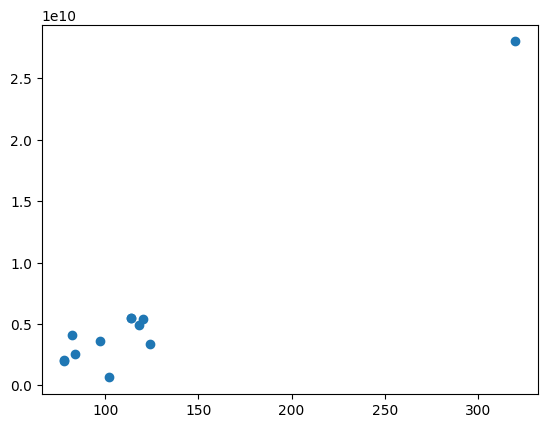

In [36]:
plt.scatter(sattar['Area'], sattar['Price'])
plt.show()

In [37]:
df = df.drop(3193)

In [38]:
lavasan = df[df['Address'] == 'Lavasan']
lavasan

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
431,660,5,True,True,False,Lavasan,5.500000e+10,1833333.33,8.333333e+07
1349,300,3,False,False,False,Lavasan,2.700000e+10,900000.00,9.000000e+07
2779,300,5,True,True,False,Lavasan,2.500000e+10,833333.33,8.333333e+07


In [39]:
df.nsmallest(10, 'Price Per Meter')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
136,160,1,False,False,False,Qarchak,3.600000e+06,120.00,2.250000e+04
2770,83,2,True,True,True,Ozgol,5.500000e+07,1833.33,6.626506e+05
731,75,2,True,True,True,Pardis,6.000000e+07,2000.00,8.000000e+05
2721,110,0,True,True,True,Parand,1.020000e+08,3400.00,9.272727e+05
2201,49,1,True,True,False,Andisheh,1.100000e+08,3666.67,2.244898e+06
3300,120,3,True,True,True,Persian Gulf Martyrs Lake,2.950000e+08,9833.33,2.458333e+06
1343,78,2,True,True,True,Parand,2.100000e+08,7000.00,2.692308e+06
3149,118,2,True,True,True,Northern Chitgar,3.200000e+08,10666.67,2.711864e+06
1443,350,3,True,True,False,Pasdaran,1.000000e+09,33333.33,2.857143e+06
1543,123,2,True,True,True,Persian Gulf Martyrs Lake,3.600000e+08,12000.00,2.926829e+06


In [40]:
df = df.drop([136, 2770, 731, 2721])

In [41]:
df.nlargest(10, 'Price')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
1707,420,4,True,True,True,Zaferanieh,9.240000e+10,3080000.00,2.200000e+08
1810,705,5,True,True,False,Abazar,9.100000e+10,3033333.33,1.290780e+08
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
819,680,5,True,True,False,Ekhtiarieh,8.160000e+10,2720000.00,1.200000e+08
1332,350,4,True,True,True,Niavaran,8.050000e+10,2683333.33,2.300000e+08
1694,929,5,True,True,False,Zafar,8.000000e+10,2666666.67,8.611410e+07
3051,530,4,True,True,True,Dorous,7.950000e+10,2650000.00,1.500000e+08
831,750,5,True,True,True,Mahmoudieh,7.500000e+10,2500000.00,1.000000e+08
2394,310,3,True,True,True,Aqdasieh,7.440000e+10,2480000.00,2.400000e+08
2194,350,4,True,True,True,Niavaran,7.200000e+10,2400000.00,2.057143e+08


In [42]:
df = df.drop(1810)

In [43]:
df.nsmallest(10, 'Price')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
2201,49,1,True,True,False,Andisheh,110000000.0,3666.67,2.244898e+06
137,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
2084,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
1343,78,2,True,True,True,Parand,210000000.0,7000.00,2.692308e+06
2666,48,1,False,True,False,Shahedshahr,210000000.0,7000.00,4.375000e+06
2921,45,1,False,True,False,Islamshahr,218000000.0,7266.67,4.844444e+06
2929,58,1,False,False,False,Parand,235000000.0,7833.33,4.051724e+06
2925,50,1,False,True,False,Islamshahr,240000000.0,8000.00,4.800000e+06
2553,75,2,False,False,False,Parand,245000000.0,8166.67,3.266667e+06
3432,58,1,False,False,True,Parand,246000000.0,8200.00,4.241379e+06


In [44]:
stats = df.groupby('Address')['Price Per Meter'].agg(['mean', 'count'])
stats.nlargest(10, 'mean')

,mean,count
Address,,
Gandhi,1.400000e+08,1
Vanak,1.274156e+08,2
Lavasan,1.172917e+08,4
Zaferanieh,1.137139e+08,27
Elahieh,1.122126e+08,17
Velenjak,1.116799e+08,22
Kamranieh,1.036243e+08,14
Niavaran,1.027806e+08,68
Farmanieh,1.023298e+08,57


In [45]:
stats.loc['Amir Bahador']

mean     6.098246e+07
count    4.000000e+00
Name: Amir Bahador, dtype: float64

<Axes: xlabel='Elevator', ylabel='Price'>

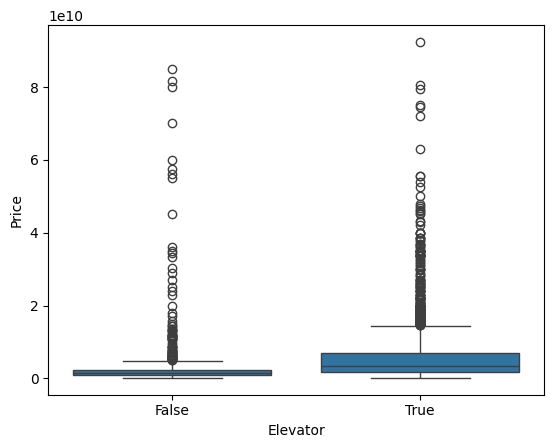

In [46]:
sns.boxplot(data=df, x='Elevator', y='Price')

In [47]:
elev = df[df['Elevator'] == False]
elev.nlargest(10, "Price Per Meter")

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
1635,287,5,True,True,False,Vanak,5.750000e+10,1916666.67,2.003484e+08
879,250,3,True,True,False,Niavaran,4.500000e+10,1500000.00,1.800000e+08
3031,57,1,False,True,False,Amir Bahador,9.800000e+09,326666.67,1.719298e+08
2960,212,4,True,True,False,Farmanieh,3.600000e+10,1200000.00,1.698113e+08
2598,180,5,True,True,False,Shahrake Gharb,2.880000e+10,960000.00,1.600000e+08
3254,240,3,True,True,False,Elahieh,3.456000e+10,1152000.00,1.440000e+08
1119,250,4,True,True,False,Shahrake Gharb,3.500000e+10,1166666.67,1.400000e+08
1270,400,5,True,True,False,Mirdamad,5.600000e+10,1866666.67,1.400000e+08
2706,500,5,True,True,False,Gandhi,7.000000e+10,2333333.33,1.400000e+08


In [48]:
molavi = df[df['Address'] == 'Amir Bahador']
molavi.value_counts()

Area  Room  Parking  Warehouse  Elevator  Address       Price         Price(USD)  Price Per Meter
57    1     False    True       False     Amir Bahador  9.800000e+09  326666.67   1.719298e+08       1
63    2     True     True       True      Amir Bahador  1.638000e+09  54600.00    2.600000e+07       1
74    2     True     True       True      Amir Bahador  1.702000e+09  56733.33    2.300000e+07       1
93    2     True     True       True      Amir Bahador  2.139000e+09  71300.00    2.300000e+07       1
Name: count, dtype: int64

In [49]:
df = df.drop(3031)

<Axes: xlabel='Warehouse', ylabel='Price'>

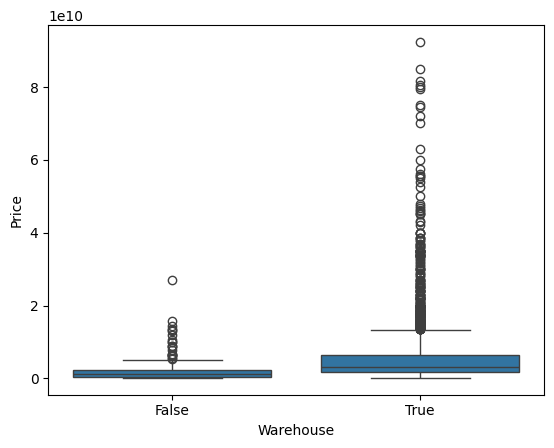

In [50]:
sns.boxplot(data=df, x='Warehouse', y='Price')

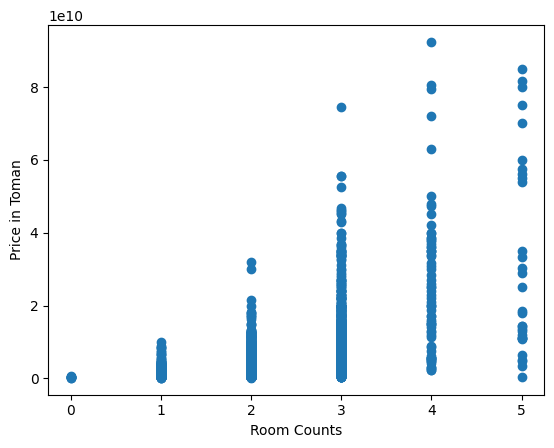

In [51]:
plt.scatter(df['Room'], df['Price'])
plt.xlabel("Room Counts")
plt.ylabel("Price in Toman")
plt.show()

In [52]:
zero = df[df["Room"] == 0]

In [53]:
zero

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
103,40,0,False,False,False,Shahrake Qods,248000000.0,8266.67,6.200000e+06
137,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
1169,40,0,False,True,False,Ostad Moein,650000000.0,21666.67,1.625000e+07
2084,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
2103,43,0,False,True,False,Nasim Shahr,360000000.0,12000.00,8.372093e+06
2625,50,0,True,True,True,Northern Chitgar,345000000.0,11500.00,6.900000e+06
3211,30,0,False,True,False,Ostad Moein,500000000.0,16666.67,1.666667e+07
3435,54,0,False,False,False,Shahrake Qods,470000000.0,15666.67,8.703704e+06


## 7. Listings far off their neighbourhood's price

Each listing's price per m² is compared to its neighbourhood's median. Listings many times above or below it are likely errors and are removed.

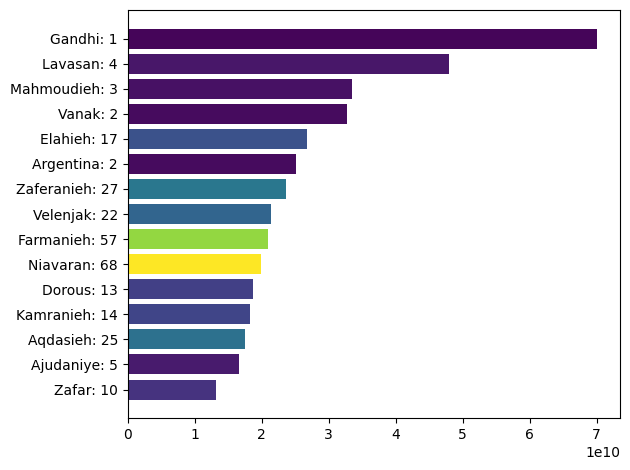

In [54]:
neigh = df.groupby("Address")['Price'].agg(['mean','count']).nlargest(15, 'mean').sort_values('mean')
labels = neigh.index + ': ' + neigh['count'].astype(str)
plt.barh(labels, neigh['mean'], color=plt.cm.viridis(neigh['count']/neigh['count'].max()))
plt.tight_layout()
plt.show()

In [55]:
nb_median = df.groupby("Address")["Price Per Meter"].transform("median")
ratio = df["Price Per Meter"]/nb_median
nb_count = df.groupby("Address")["Price"].transform("size")
check = pd.DataFrame({
    'Address': df['Address'],
    'ratio': ratio,
    'nb_count': nb_count
})
print(f'top overpriced:\n {check.nlargest(20, "ratio")}\n')
print(f'top underpriced:\n {check.nsmallest(20, "ratio")}')

top overpriced:
                          Address      ratio  nb_count
3420                 Si Metri Ji  10.396011        23
2331                    Golestan   7.150084        16
2583                    Damavand   6.923077        23
1973                    Damavand   4.235294        23
2332                      Pardis   3.613846       145
2842                      Pardis   3.480000       145
2394                    Aqdasieh   3.428571        25
2532                      Narmak   3.077098        25
2689  North Program Organization   3.071672        27
2314                    Shahryar   3.023305        12
1104                      Parand   2.919230       126
595                       Pardis   2.889860       145
946                     Golestan   2.730935        16
1789                    Damavand   2.710084        23
3267                  Azarbaijan   2.675740        24
1407  North Program Organization   2.675673        27
3198                      Parand   2.649241       126
2282       

In [56]:
df.loc[ratio.nlargest(10).index]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3420,45,1,False,False,True,Si Metri Ji,8.900000e+09,296666.67,1.977778e+08
2331,300,3,True,True,False,Golestan,2.400000e+10,800000.00,8.000000e+07
2583,130,1,True,True,False,Damavand,8.500000e+09,283333.33,6.538462e+07
1973,500,4,True,True,False,Damavand,2.000000e+10,666666.67,4.000000e+07
2332,100,2,True,True,False,Pardis,2.700000e+09,90000.00,2.700000e+07
2842,150,3,True,True,True,Pardis,3.900000e+09,130000.00,2.600000e+07
2394,310,3,True,True,True,Aqdasieh,7.440000e+10,2480000.00,2.400000e+08
2532,210,4,True,True,False,Narmak,2.300000e+10,766666.67,1.095238e+08
2689,253,5,True,True,False,North Program Organization,3.036000e+10,1012000.00,1.200000e+08
2314,220,4,True,True,False,Shahryar,7.500000e+09,250000.00,3.409091e+07


In [57]:
df.loc[ratio.nsmallest(10).index]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
1443,350,3,True,True,False,Pasdaran,1.000000e+09,33333.33,2.857143e+06
2927,75,2,True,True,True,Saadat Abad,3.150000e+08,10500.00,4.200000e+06
3300,120,3,True,True,True,Persian Gulf Martyrs Lake,2.950000e+08,9833.33,2.458333e+06
1543,123,2,True,True,True,Persian Gulf Martyrs Lake,3.600000e+08,12000.00,2.926829e+06
3301,90,2,True,True,True,Persian Gulf Martyrs Lake,2.900000e+08,9666.67,3.222222e+06
3265,125,2,True,True,True,Gheitarieh,1.125000e+09,37500.00,9.000000e+06
3027,134,2,True,True,True,Mehran,9.400000e+08,31333.33,7.014925e+06
768,400,3,True,True,False,Amirabad,2.000000e+09,66666.67,5.000000e+06
2742,80,1,True,True,True,Gheitarieh,8.500000e+08,28333.33,1.062500e+07
2612,100,2,True,True,True,Persian Gulf Martyrs Lake,4.350000e+08,14500.00,4.350000e+06


In [58]:
df = df.drop([3420, 2331, 2583, 2332, 2842, 1443, 2927])

## 8. Preparing the data for modeling

Neighbourhoods with fewer than 5 listings are grouped into `Other`, then all neighbourhoods are one-hot encoded.

In [59]:
counts = df["Address"].value_counts()
rare = counts[counts<5].index

model_df = df.copy()
model_df['Address'] = model_df['Address'].replace(rare, 'Other')

model_df = pd.get_dummies(model_df, columns=['Address'], drop_first=True, dtype=int)

print(len(counts))
print(len(rare))

192
95


In [60]:
print(f'most expensive house: {df["Price"].max()}')
print(f'least expensive house: {df["Price"].min()}')

most expensive house: 92400000000.0
least expensive house: 110000000.0


## 9. First models: linear vs. log (5-fold cross-validation)

The data is split 80/20 and the test set is kept aside until the end. Two models are compared on the training set:
- **Linear**: predicts price directly
- **Log**: predicts log(price), then converts back. Useful because prices range from millions to tens of billions

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, root_mean_squared_error, mean_squared_error

x = model_df.drop(columns = ['Price', 'Price Per Meter', 'Price(USD)'])
y = model_df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
pred = cross_val_predict(LinearRegression(), x_train, y_train, cv=kf)

print(f'mean absolute error: {mean_absolute_error(y_train, pred)}')
print(f'r2 score: {r2_score(y_train, pred)}')
print(f'median absolute error: {median_absolute_error(y_train, pred)}')
print(f'maximum predicted: {pred.max()}')
print(f'minimum predicted: {pred.min()}')

mean absolute error: 1960878215.8768394
r2 score: 0.7423845090094234
median absolute error: 1020804679.5745821
maximum predicted: 85020192114.18756
minimum predicted: -9779295115.452398


In [62]:
#trying log model

pred_log = np.exp(cross_val_predict(LinearRegression(), x_train, np.log(y_train), cv=kf))

print(f'log-scale r2: {r2_score(np.log(y_train), np.log(pred_log))}')
print(f'median absolute error: {median_absolute_error(y_train, pred_log)}')
print(f'mean absolute error: {mean_absolute_error(y_train, pred_log)}')
print(f'maximum predicted: {pred_log.max()}')
print(f'minimum predicted: {pred_log.min()}')

log-scale r2: 0.8890285922886557
median absolute error: 428913783.6803726
mean absolute error: 2078811153.710633
maximum predicted: 1680311866017.5457
minimum predicted: 215877782.85219115


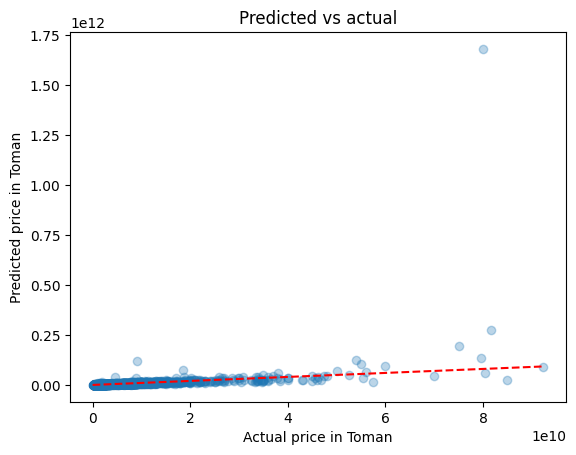

In [63]:
plt.scatter(y_train, pred_log, alpha=0.3)
plt.plot([0, y_train.max()], [0, y_train.max()], 'r--')
plt.xlabel('Actual price in Toman')
plt.ylabel('Predicted price in Toman')
plt.title('Predicted vs actual')
plt.show()

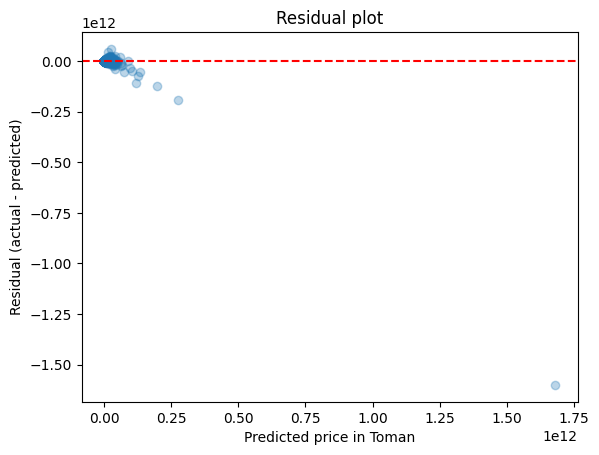

In [64]:
residuals_log = y_train - pred_log
plt.scatter(pred_log, residuals_log, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted price in Toman')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot')
plt.show()

In [65]:
residuals_log.sort_values().head(10)

1694   -1.600312e+12
819    -1.927683e+11
831    -1.212912e+11
1236   -1.081286e+11
583    -7.103518e+10
742    -5.552701e+10
3051   -5.472518e+10
431    -4.717375e+10
2481   -3.739412e+10
1407   -3.571946e+10
Name: Price, dtype: float64

In [66]:
df.loc[residuals_log.abs().idxmax()]

Area                           929
Room                             5
Parking                       True
Warehouse                     True
Elevator                     False
Address                      Zafar
Price                80000000000.0
Price(USD)              2666666.67
Price Per Meter    86114101.184069
Name: 1694, dtype: object

In [67]:
zafar = df[df['Address'] == 'Zafar']
zafar

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
14,95,2,True,True,True,Zafar,5.000000e+09,166666.67,5.263158e+07
1694,929,5,True,True,False,Zafar,8.000000e+10,2666666.67,8.611410e+07
1741,110,2,False,True,True,Zafar,5.550000e+09,185000.00,5.045455e+07
2188,144,3,True,True,True,Zafar,1.036800e+10,345600.00,7.200000e+07
2268,60,1,True,True,True,Zafar,1.200000e+09,40000.00,2.000000e+07
2418,70,2,True,True,True,Zafar,5.250000e+09,175000.00,7.500000e+07
2578,126,3,True,True,True,Zafar,7.676000e+09,255866.67,6.092063e+07
2591,85,2,True,True,True,Zafar,5.000000e+09,166666.67,5.882353e+07
2858,150,3,False,True,False,Zafar,6.000000e+09,200000.00,4.000000e+07
3038,110,2,True,True,True,Zafar,5.700000e+09,190000.00,5.181818e+07


In [ ]:
print(f'top underpredicted:\n{residuals_log.nlargest(10)}')
print(f'\ntop overpredicted:\n{residuals_log.nsmallest(10)}')

top underpredicted:
430     6.045272e+10
1635    4.434451e+10
2706    2.770524e+10
1565    2.413071e+10
879     2.325432e+10
1332    2.269980e+10
440     2.168729e+10
1415    2.073681e+10
1366    2.007071e+10
2722    1.892641e+10
Name: Price, dtype: float64

top overpredicted:
1694   -1.600312e+12
819    -1.927683e+11
831    -1.212912e+11
1236   -1.081286e+11
583    -7.103518e+10
742    -5.552701e+10
3051   -5.472518e+10
431    -4.717375e+10
2481   -3.739412e+10
1407   -3.571946e+10
Name: Price, dtype: float64


## 10. Removing very large properties (600 m² and over)

The biggest errors came from very large properties. There are only a handful of them, and they behave like a different market.

In [69]:
big = df[df['Area']>= 600]
len(big)

12

In [70]:
big

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
356,650,2,True,True,False,Absard,5.200000e+09,173333.33,8.000000e+06
431,660,5,True,True,False,Lavasan,5.500000e+10,1833333.33,8.333333e+07
807,1000,2,True,True,False,Damavand,7.000000e+09,233333.33,7.000000e+06
819,680,5,True,True,False,Ekhtiarieh,8.160000e+10,2720000.00,1.200000e+08
831,750,5,True,True,True,Mahmoudieh,7.500000e+10,2500000.00,1.000000e+08
1236,600,2,True,True,True,Qalandari,9.150000e+09,305000.00,1.525000e+07
1694,929,5,True,True,False,Zafar,8.000000e+10,2666666.67,8.611410e+07
1974,900,3,True,True,False,Damavand,8.500000e+09,283333.33,9.444444e+06
2481,700,3,True,True,False,Damavand,4.500000e+09,150000.00,6.428571e+06
2647,700,3,True,True,False,Damavand,7.000000e+09,233333.33,1.000000e+07


In [71]:
print(len(df))
df = df[df["Area"]<600]
len(df)

3433


3421

In [72]:
counts = df["Address"].value_counts()
rare = counts[counts<5].index

model_df = df.copy()
model_df['Address'] = model_df['Address'].replace(rare, 'Other')

model_df = pd.get_dummies(model_df, columns=['Address'], drop_first=True, dtype=int)

print(len(counts))
print(len(rare))

191
94


In [73]:
x = model_df.drop(columns = ['Price', 'Price Per Meter', 'Price(USD)'])
y = model_df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
pred = cross_val_predict(LinearRegression(), x_train, y_train, cv=kf)

print(f'mean absolute error: {mean_absolute_error(y_train, pred)}')
print(f'r2 score: {r2_score(y_train, pred)}')
print(f'median absolute error: {median_absolute_error(y_train, pred)}')
print(f'maximum predicted: {pred.max()}')
print(f'minimum predicted: {pred.min()}')

mean absolute error: 1931901304.4014747
r2 score: 0.7338575561287279
median absolute error: 1050027551.1503663
maximum predicted: 48579956942.01257
minimum predicted: -12087098715.068707


In [74]:
#trying log model

pred_log = np.exp(cross_val_predict(LinearRegression(), x_train, np.log(y_train), cv=kf))

print(f'log-scale r2: {r2_score(np.log(y_train), np.log(pred_log))}')
print(f'median absolute error: {median_absolute_error(y_train, pred_log)}')
print(f'mean absolute error: {mean_absolute_error(y_train, pred_log)}')
print(f'maximum predicted: {pred_log.max()}')
print(f'minimum predicted: {pred_log.min()}')

log-scale r2: 0.8971458898686593
median absolute error: 399912866.6977645
mean absolute error: 1445137301.0314233
maximum predicted: 261181652528.56613
minimum predicted: 180356985.92297652


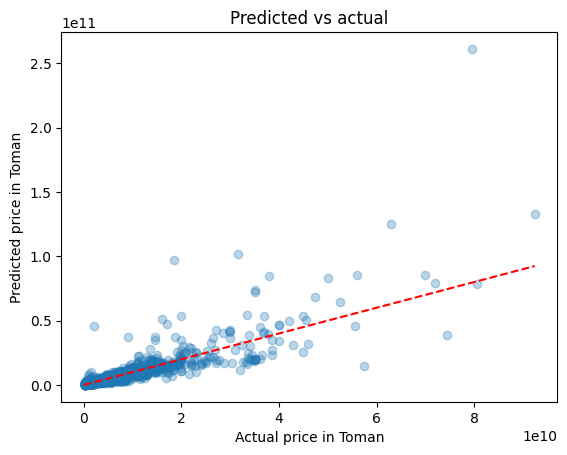

In [75]:
plt.scatter(y_train, pred_log, alpha=0.3)
plt.plot([0, y_train.max()], [0, y_train.max()], 'r--')
plt.xlabel('Actual price in Toman')
plt.ylabel('Predicted price in Toman')
plt.title('Predicted vs actual')
plt.show()

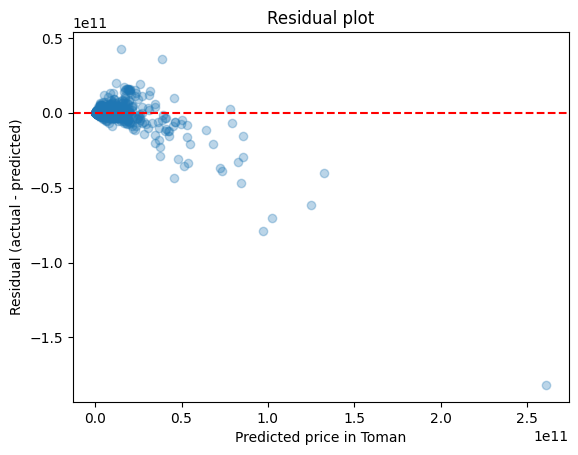

In [76]:
residuals_log = y_train - pred_log
plt.scatter(pred_log, residuals_log, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted price in Toman')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot')
plt.show()

In [77]:
residuals_log.sort_values().head(10)

3051   -1.816817e+11
742    -7.893359e+10
1275   -7.043224e+10
1863   -6.180505e+10
1408   -4.667237e+10
768    -4.360684e+10
1707   -4.035116e+10
1488   -3.861172e+10
2693   -3.699897e+10
1740   -3.526370e+10
Name: Price, dtype: float64

In [78]:
df.loc[residuals_log.abs().idxmax()]

Area                         530
Room                           4
Parking                     True
Warehouse                   True
Elevator                    True
Address                   Dorous
Price              79500000000.0
Price(USD)             2650000.0
Price Per Meter      150000000.0
Name: 3051, dtype: object

In [79]:
daroos = df[df["Address"] == "Dorous"]
daroos.sort_values("Price", ascending=False)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3051,530,4,True,True,True,Dorous,7.950000e+10,2650000.00,1.500000e+08
1008,365,4,True,True,True,Dorous,4.745000e+10,1581666.67,1.300000e+08
365,256,3,True,True,True,Dorous,1.850000e+10,616666.67,7.226562e+07
102,130,2,True,True,True,Dorous,1.690000e+10,563333.33,1.300000e+08
364,179,3,True,True,True,Dorous,1.380000e+10,460000.00,7.709497e+07
741,161,3,True,True,True,Dorous,1.300000e+10,433333.33,8.074534e+07
1095,190,3,True,True,True,Dorous,1.200000e+10,400000.00,6.315789e+07
1192,135,2,True,True,True,Dorous,1.000000e+10,333333.33,7.407407e+07
1755,155,3,True,True,True,Dorous,9.800000e+09,326666.67,6.322581e+07
1281,133,3,True,True,True,Dorous,8.600000e+09,286666.67,6.466165e+07


In [80]:
df = df.drop(3051)

In [81]:
counts = df["Address"].value_counts()
rare = counts[counts<5].index

model_df = df.copy()
model_df['Address'] = model_df['Address'].replace(rare, 'Other')

model_df = pd.get_dummies(model_df, columns=['Address'], drop_first=True, dtype=int)

print(len(counts))
print(len(rare))

191
94


In [82]:
x = model_df.drop(columns = ['Price', 'Price Per Meter', 'Price(USD)'])
y = model_df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
pred = cross_val_predict(LinearRegression(), x_train, y_train, cv=kf)

print(f'mean absolute error: {mean_absolute_error(y_train, pred)}')
print(f'r2 score: {r2_score(y_train, pred)}')
print(f'median absolute error: {median_absolute_error(y_train, pred)}')
print(f'maximum predicted: {pred.max()}')
print(f'minimum predicted: {pred.min()}')

mean absolute error: 1838750693.7015152
r2 score: 0.7025828069682685
median absolute error: 919312341.8909569
maximum predicted: 43523187474.784
minimum predicted: -11480649538.090384


In [83]:
#trying log model

pred_log = np.exp(cross_val_predict(LinearRegression(), x_train, np.log(y_train), cv=kf))

print(f'log-scale r2: {r2_score(np.log(y_train), np.log(pred_log))}')
print(f'median absolute error: {median_absolute_error(y_train, pred_log)}')
print(f'mean absolute error: {mean_absolute_error(y_train, pred_log)}')
print(f'maximum predicted: {pred_log.max()}')
print(f'minimum predicted: {pred_log.min()}')

log-scale r2: 0.8890569390489261
median absolute error: 386584189.5872457
mean absolute error: 1453063731.1867878
maximum predicted: 178220383365.0481
minimum predicted: 190082414.1075462


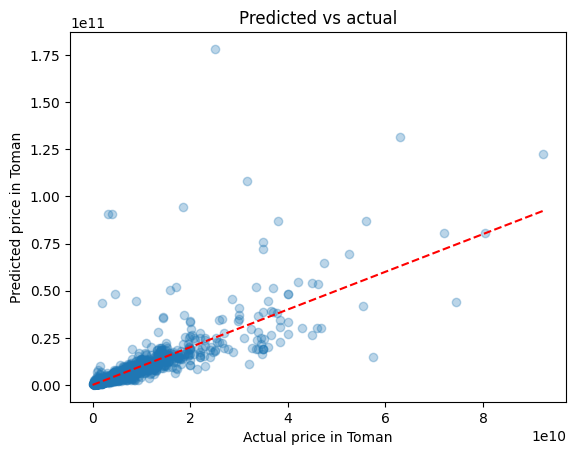

In [84]:
plt.scatter(y_train, pred_log, alpha=0.3)
plt.plot([0, y_train.max()], [0, y_train.max()], 'r--')
plt.xlabel('Actual price in Toman')
plt.ylabel('Predicted price in Toman')
plt.title('Predicted vs actual')
plt.show()

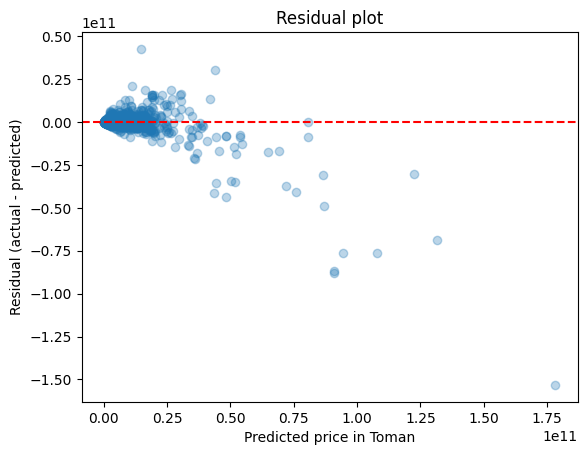

In [85]:
residuals_log = y_train - pred_log
plt.scatter(pred_log, residuals_log, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted price in Toman')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot')
plt.show()

In [86]:
residuals_log.nsmallest(10)

2476   -1.532204e+11
2179   -8.769153e+10
285    -8.689153e+10
1275   -7.625771e+10
742    -7.612216e+10
1863   -6.868860e+10
1408   -4.913069e+10
1970   -4.385101e+10
768    -4.159811e+10
1488   -4.073471e+10
Name: Price, dtype: float64

In [87]:
df.loc[residuals_log.nsmallest(10).index]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
2476,450,4,True,True,True,Niavaran,2.500000e+10,833333.33,5.555556e+07
2179,500,2,True,True,False,Absard,3.100000e+09,103333.33,6.200000e+06
285,500,2,True,True,False,Absard,3.900000e+09,130000.00,7.800000e+06
1275,377,4,True,True,True,Elahieh,3.166800e+10,1055600.00,8.400000e+07
742,400,5,True,True,True,Ekhtiarieh,1.850000e+10,616666.67,4.625000e+07
1863,400,4,True,True,True,Elahieh,6.300000e+10,2100000.00,1.575000e+08
1408,360,4,True,True,True,Niavaran,3.800000e+10,1266666.67,1.055556e+08
1970,450,2,False,False,False,Absard,4.500000e+09,150000.00,1.000000e+07
768,400,3,True,True,False,Amirabad,2.000000e+09,66666.67,5.000000e+06
1488,350,5,True,True,True,Gheitarieh,3.500000e+10,1166666.67,1.000000e+08


## 11. Limiting the model to homes under 300 m²

Removing properties over 600 m² helped, but after re-running the models the biggest errors were still coming from large homes, this time in the 350–500 m² range (see the table above). There are few of them, and their prices vary a lot even within the same neighbourhood, so the model can't learn them well. Since most of the listings are small apartments, I focus the model on homes under 300 m², where it predicts much more reliably.

In [88]:
df = df[df["Area"]<300]

In [89]:
counts = df["Address"].value_counts()
rare = counts[counts<5].index

model_df = df.copy()
model_df['Address'] = model_df['Address'].replace(rare, 'Other')

model_df = pd.get_dummies(model_df, columns=['Address'], drop_first=True, dtype=int)

print(len(counts))
print(len(rare))

187
93


In [90]:
x = model_df.drop(columns = ['Price', 'Price Per Meter', 'Price(USD)'])
y = model_df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
pred = cross_val_predict(LinearRegression(), x_train, y_train, cv=kf)

print(f'mean absolute error: {mean_absolute_error(y_train, pred)}')
print(f'r2 score: {r2_score(y_train, pred)}')
print(f'median absolute error: {median_absolute_error(y_train, pred)}')
print(f'maximum predicted: {pred.max()}')
print(f'minimum predicted: {pred.min()}')

mean absolute error: 1479897711.016721
r2 score: 0.796004968618093
median absolute error: 853941826.3746135
maximum predicted: 29779928413.50611
minimum predicted: -4543395259.961226


In [91]:
#trying log model

pred_log = np.exp(cross_val_predict(LinearRegression(), x_train, np.log(y_train), cv=kf))

print(f'log-scale r2: {r2_score(np.log(y_train), np.log(pred_log))}')
print(f'median absolute error: {median_absolute_error(y_train, pred_log)}')
print(f'mean absolute error: {mean_absolute_error(y_train, pred_log)}')
print(f'maximum predicted: {pred_log.max()}')
print(f'minimum predicted: {pred_log.min()}')

log-scale r2: 0.9041323427802961
median absolute error: 359052251.5609586
mean absolute error: 1115271470.1050575
maximum predicted: 64013912652.10239
minimum predicted: 229915528.45638725


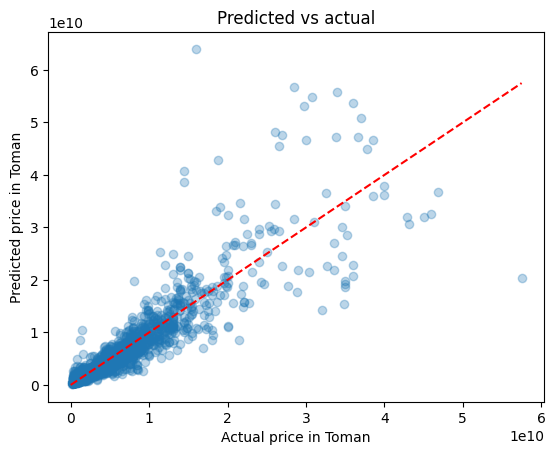

In [92]:
plt.scatter(y_train, pred_log, alpha=0.3)
plt.plot([0, y_train.max()], [0, y_train.max()], 'r--')
plt.xlabel('Actual price in Toman')
plt.ylabel('Predicted price in Toman')
plt.title('Predicted vs actual')
plt.show()

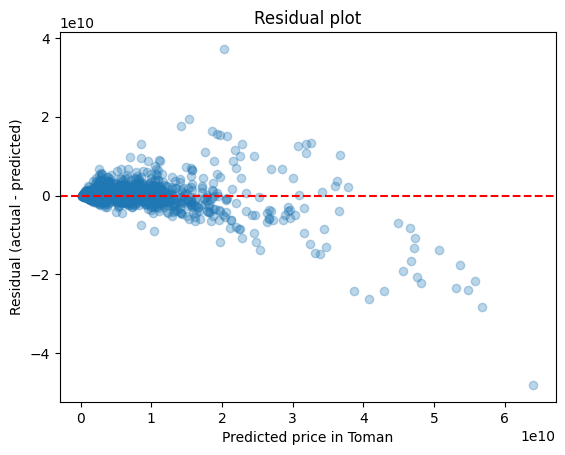

In [93]:
residuals_log = y_train - pred_log
plt.scatter(pred_log, residuals_log, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted price in Toman')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot')
plt.show()

## 12. Final test

Both models are trained on the full training set and scored once on the untouched test set, then used to predict the price of an example house (150 m², 3 rooms, parking, warehouse, elevator, Elahieh).

In [94]:
test = pd.DataFrame(0, index=[0], columns=x_train.columns)
test['Area'] = 150
test['Room'] = 3
test['Parking'] = 1
test['Warehouse'] = 1
test['Elevator'] = 1
test['Address_Elahieh'] = 1

test

,Area,Room,Parking,Warehouse,Elevator,Address_Afsarieh,Address_Air force,Address_Amirabad,Address_Amirieh,Address_Andisheh,...,Address_Tarasht,Address_Tehransar,Address_Tenant,Address_Valiasr,Address_Velenjak,Address_West Ferdows Boulevard,Address_West Pars,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh
0,150,3,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
model_lin = LinearRegression().fit(x_train, y_train)
print(f'predicted price: {model_lin.predict(test)[0]:,.0f}')
print(f'test r2 score: {r2_score(y_test, model_lin.predict(x_test)):.3f}')

predicted price: 18,662,265,513
test r2 score: 0.795


In [96]:
model_log = LinearRegression().fit(x_train, np.log(y_train))
print(f'predicted price: {np.exp(model_log.predict(test)[0]):,.0f}')
print(f'test r2 score: {r2_score(y_test, np.exp(model_log.predict(x_test))):.3f}')

predicted price: 13,293,486,337
test r2 score: 0.787


The 80% range is based on how far off the log model was on the test houses: in 80% of cases, the real price fell within this range around the prediction.

In [97]:
errors = np.log(y_test) - model_log.predict(x_test)
low, high = np.exp(np.percentile(errors, [10, 90]))
p = np.exp(model_log.predict(test)[0])
print(f'80% chance the real price is between {p*low:,.0f} and {p*high:,.0f}')

80% chance the real price is between 10,017,204,733 and 18,347,097,118
